# Algoritmo Genético para ruteo y scheduling de camiones cisterna

Este notebook desarrolla una implementación reproducible de un **Algoritmo Genético (GA)** para el
problema de distribución de combustibles con camiones cisterna de doble compartimento.

El objetivo computacional es construir, evaluar y visualizar una solución factible que cumpla:

- satisfacción completa de la demanda del escenario normal;
- compatibilidad entre producto y compartimento;
- capacidad máxima de cada compartimento;
- estabilidad de carga con \(\Delta = 0.30\);
- ventanas de tiempo en estaciones;
- scheduling de carga en depósito;
- minimización del costo compuesto por distancia, costos fijos y penalización por shortage.

La solución reportada por el GA es:

| Camión | Ruta | C0 | C1 | Carga C0 | Carga C1 |
|---|---|---|---|---:|---:|
| T1 | Depósito → 1 → 2 → 4 → Depósito | Regular | Diésel | 8000 L | 6000 L |
| T2 | Depósito → 3 → Depósito | Diésel | Regular | 3000 L | 2500 L |

Costo total:

\[
C = 2(115) + 500 + 400 + 10(0) = 1130.
\]


## 1. Preparación del entorno

Se cargan las librerías necesarias para trabajar con estructuras de datos, ejecutar el algoritmo
y generar evidencia gráfica. Las figuras se guardan en la carpeta `figuras_ga/`.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

FIG_DIR = Path("figuras_ga")
FIG_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "font.size": 9,
})


## 2. Datos del problema

Se define el escenario normal como demanda determinista. El depósito se representa con el nodo `0`,
y las estaciones con los nodos `1`, `2`, `3` y `4`.

Las ventanas de tiempo se expresan en minutos desde las 00:00 para simplificar los cálculos.


In [3]:
COSTO_KM = 2
PENALIZACION_SHORTAGE = 10
TIEMPO_SERVICIO = 30
DELTA = 0.30

PRODUCTOS = {"R": "Regular", "D": "Diésel"}


def minuto(hora: str) -> int:
    h, m = map(int, hora.split(":"))
    return 60 * h + m


def hhmm(valor: float) -> str:
    valor = int(round(valor))
    return f"{valor // 60:02d}:{valor % 60:02d}"


DEMANDA_NORMAL = {
    1: {"R": 3000, "D": 2000},
    2: {"R": 4000, "D": 1500},
    3: {"R": 2500, "D": 3000},
    4: {"R": 1000, "D": 2500},
}

VENTANAS = {
    1: (minuto("06:00"), minuto("10:00")),
    2: (minuto("07:00"), minuto("12:00")),
    3: (minuto("08:00"), minuto("14:00")),
    4: (minuto("06:00"), minuto("11:00")),
}

DIST = {
    0: {0: 0, 1: 20, 2: 35, 3: 15, 4: 40},
    1: {0: 20, 1: 0, 2: 10, 3: 25, 4: 30},
    2: {0: 35, 1: 10, 2: 0, 3: 20, 4: 15},
    3: {0: 15, 1: 25, 2: 20, 3: 0, 4: 30},
    4: {0: 40, 1: 30, 2: 15, 3: 30, 4: 0},
}

ESCENARIOS = {
    "s=1 Normal": {
        "prob": 0.5,
        "demanda": DEMANDA_NORMAL,
    },
    "s=2 Alta": {
        "prob": 0.3,
        "demanda": {
            1: {"R": 4500, "D": 2800},
            2: {"R": 5500, "D": 2000},
            3: {"R": 3500, "D": 3000},
            4: {"R": 1000, "D": 2500},
        },
    },
    "s=3 Baja": {
        "prob": 0.2,
        "demanda": {
            1: {"R": 2000, "D": 1200},
            2: {"R": 3000, "D": 1000},
            3: {"R": 1800, "D": 3000},
            4: {"R": 1000, "D": 2500},
        },
    },
}


## 3. Entidades principales

El código usa clases pequeñas para representar entidades del problema:

- `Compartimento`: capacidad de cada tanque del camión.
- `Camion`: capacidades, costo fijo y hora de salida.
- `Estacion`: demanda por producto y ventana de tiempo.

Estas entidades mantienen el código cercano a la formulación del problema.


In [4]:
@dataclass(frozen=True)
class Compartimento:
    nombre: str
    capacidad: float


@dataclass(frozen=True)
class Camion:
    nombre: str
    compartimentos: dict[str, Compartimento]
    costo_fijo: float
    salida_min: int


@dataclass(frozen=True)
class Estacion:
    id: int
    demanda: dict[str, float]
    ventana: tuple[int, int]


CAMIONES = {
    "T1": Camion(
        "T1",
        {"C0": Compartimento("C0", 8000), "C1": Compartimento("C1", 7000)},
        costo_fijo=500,
        salida_min=minuto("05:00"),
    ),
    "T2": Camion(
        "T2",
        {"C0": Compartimento("C0", 6000), "C1": Compartimento("C1", 9000)},
        costo_fijo=400,
        salida_min=minuto("05:30"),
    ),
}

ESTACIONES = {
    j: Estacion(j, DEMANDA_NORMAL[j], VENTANAS[j])
    for j in [1, 2, 3, 4]
}

estaciones_df = pd.DataFrame([
    {
        "Estación": j,
        "Regular (L)": e.demanda["R"],
        "Diésel (L)": e.demanda["D"],
        "Ventana": f"[{hhmm(e.ventana[0])}, {hhmm(e.ventana[1])}]",
    }
    for j, e in ESTACIONES.items()
])

camiones_df = pd.DataFrame([
    {
        "Camión": k,
        "Capacidad C0": c.compartimentos["C0"].capacidad,
        "Capacidad C1": c.compartimentos["C1"].capacidad,
        "Costo fijo": c.costo_fijo,
        "Salida": hhmm(c.salida_min),
    }
    for k, c in CAMIONES.items()
])

display(estaciones_df)
display(camiones_df)


,Estación,Regular (L),Diésel (L),Ventana
0,1,3000,2000,"[06:00, 10:00]"
1,2,4000,1500,"[07:00, 12:00]"
2,3,2500,3000,"[08:00, 14:00]"
3,4,1000,2500,"[06:00, 11:00]"


,Camión,Capacidad C0,Capacidad C1,Costo fijo,Salida
0,T1,8000,7000,500,05:00
1,T2,6000,9000,400,05:30


## 4. Representación del cromosoma

Un cromosoma contiene tres elementos:

1. `orden`: permutación de las estaciones.
2. `corte`: punto que separa qué estaciones atiende T1 y cuáles atiende T2.
3. `asignacion`: producto asignado a C0 y C1 en cada camión.

Para la solución final:

```text
orden = (1, 2, 4, 3)
corte = 3
T1 = [1, 2, 4]
T2 = [3]
asignacion = (0, 1)
```

La codificación de asignación es:

- `0`: C0 transporta Regular y C1 transporta Diésel.
- `1`: C0 transporta Diésel y C1 transporta Regular.


In [5]:
@dataclass
class Cromosoma:
    orden: tuple[int, int, int, int]
    corte: int
    asignacion: tuple[int, int]
    cargas: dict[str, dict[str, float]] | None = None
    nombre: str = ""


def mapa_asignacion(bit: int) -> dict[str, str]:
    if bit == 0:
        return {"C0": "R", "C1": "D"}
    return {"C0": "D", "C1": "R"}


def asignaciones(cromosoma: Cromosoma) -> dict[str, dict[str, str]]:
    return {
        "T1": mapa_asignacion(cromosoma.asignacion[0]),
        "T2": mapa_asignacion(cromosoma.asignacion[1]),
    }


def rutas(cromosoma: Cromosoma) -> dict[str, list[int]]:
    return {
        "T1": list(cromosoma.orden[: cromosoma.corte]),
        "T2": list(cromosoma.orden[cromosoma.corte :]),
    }


def distancia_ruta(ruta: list[int]) -> float:
    if not ruta:
        return 0.0
    secuencia = [0] + ruta + [0]
    return sum(DIST[secuencia[i]][secuencia[i + 1]] for i in range(len(secuencia) - 1))


def calcular_cargas(cromosoma: Cromosoma, demanda: dict[int, dict[str, float]]) -> dict[str, dict[str, float]]:
    if cromosoma.cargas is not None:
        return {camion: dict(vals) for camion, vals in cromosoma.cargas.items()}

    cargas = {}
    for camion, ruta in rutas(cromosoma).items():
        cargas[camion] = {}
        for comp, producto in asignaciones(cromosoma)[camion].items():
            requerido = sum(demanda[j][producto] for j in ruta)
            capacidad = CAMIONES[camion].compartimentos[comp].capacidad
            cargas[camion][comp] = min(requerido, capacidad)
    return cargas


## 5. Función de evaluación

La función de evaluación convierte un cromosoma en una solución medible:

\[
C(\chi)=
2\cdot\text{distancia}+\text{costos fijos}+10\cdot\text{shortage}.
\]

Además, agrega penalizaciones cuando se viola estabilidad o ventanas de tiempo:

\[
\Phi(\chi)=C(\chi)+100000V_{\text{estabilidad}}+1000V_{\text{tiempo}}.
\]

El GA minimiza \(\Phi(\chi)\).


In [6]:
def evaluar_cromosoma(cromosoma: Cromosoma, demanda: dict[int, dict[str, float]] = DEMANDA_NORMAL) -> dict:
    rutas_camion = rutas(cromosoma)
    asignacion = asignaciones(cromosoma)
    cargas = calcular_cargas(cromosoma, demanda)

    demanda_restante = {
        j: {"R": float(vals["R"]), "D": float(vals["D"])}
        for j, vals in demanda.items()
    }

    entregas = []
    fill_records = []

    for camion in ["T1", "T2"]:
        volumen = dict(cargas[camion])

        def registrar_fill(evento: str):
            rho_c0 = volumen["C0"] / CAMIONES[camion].compartimentos["C0"].capacidad
            rho_c1 = volumen["C1"] / CAMIONES[camion].compartimentos["C1"].capacidad
            fill_records.append({
                "camion": camion,
                "evento": evento,
                "rho_C0": rho_c0,
                "rho_C1": rho_c1,
                "diferencia": abs(rho_c0 - rho_c1),
            })

        registrar_fill("Salida depósito")

        for estacion in rutas_camion[camion]:
            for comp in ["C0", "C1"]:
                producto = asignacion[camion][comp]
                cantidad = min(volumen[comp], demanda_restante[estacion][producto])
                if cantidad > 0:
                    entregas.append({
                        "camion": camion,
                        "estacion": estacion,
                        "compartimento": comp,
                        "producto": producto,
                        "litros": cantidad,
                    })
                volumen[comp] -= cantidad
                demanda_restante[estacion][producto] -= cantidad
            registrar_fill(f"Después estación {estacion}")

    shortage = sum(
        max(0.0, demanda_restante[j][p])
        for j in demanda_restante
        for p in ["R", "D"]
    )

    tiempos = []
    late_total = 0.0
    for camion, ruta in rutas_camion.items():
        tiempo_actual = CAMIONES[camion].salida_min
        nodo_anterior = 0
        for estacion in ruta:
            llegada = tiempo_actual + DIST[nodo_anterior][estacion]
            ventana_ini, ventana_fin = VENTANAS[estacion]
            inicio_servicio = max(llegada, ventana_ini)
            espera = max(0.0, ventana_ini - llegada)
            late = max(0.0, inicio_servicio - ventana_fin)
            late_total += late
            tiempos.append({
                "camion": camion,
                "estacion": estacion,
                "llegada": hhmm(llegada),
                "inicio_servicio": hhmm(inicio_servicio),
                "espera_min": espera,
                "late_min": late,
            })
            tiempo_actual = inicio_servicio + TIEMPO_SERVICIO
            nodo_anterior = estacion

    distancia_total = sum(distancia_ruta(ruta) for ruta in rutas_camion.values())
    costo_distancia = COSTO_KM * distancia_total
    costo_fijo = sum(CAMIONES[k].costo_fijo for k, ruta in rutas_camion.items() if ruta)
    costo_shortage = PENALIZACION_SHORTAGE * shortage
    costo_real = costo_distancia + costo_fijo + costo_shortage

    violacion_estabilidad = sum(
        max(0.0, row["diferencia"] - DELTA)
        for row in fill_records
    )

    costo_penalizado = (
        costo_real
        + 100000 * violacion_estabilidad
        + 1000 * late_total
    )

    return {
        "nombre": cromosoma.nombre,
        "rutas": rutas_camion,
        "asignaciones": asignacion,
        "cargas": cargas,
        "entregas": pd.DataFrame(entregas),
        "fill": pd.DataFrame(fill_records),
        "tiempos": pd.DataFrame(tiempos),
        "shortage": shortage,
        "distancia_total": distancia_total,
        "costo_distancia": costo_distancia,
        "costo_fijo": costo_fijo,
        "costo_shortage": costo_shortage,
        "costo_real": costo_real,
        "violacion_estabilidad": violacion_estabilidad,
        "late_total": late_total,
        "costo_penalizado": costo_penalizado,
        "factible": shortage <= 1e-6 and violacion_estabilidad <= 1e-9 and late_total <= 1e-9,
    }


## 6. Algoritmo Genético

El algoritmo usa:

- población inicial aleatoria;
- selección por torneo;
- crossover ordenado para rutas;
- mutación por intercambio, cambio de corte y cambio de asignación;
- elitismo para conservar las mejores soluciones.

La ejecución es reproducible mediante una semilla fija.


In [7]:
ESTACIONES_LISTA = [1, 2, 3, 4]


def crear_individuo(rng: np.random.Generator) -> Cromosoma:
    orden = tuple(rng.permutation(ESTACIONES_LISTA).tolist())
    corte = int(rng.integers(1, len(ESTACIONES_LISTA)))
    asignacion = (int(rng.integers(0, 2)), int(rng.integers(0, 2)))
    return Cromosoma(orden=orden, corte=corte, asignacion=asignacion)


def crossover_orden(a: tuple[int, ...], b: tuple[int, ...], rng: np.random.Generator) -> tuple[int, ...]:
    n = len(a)
    i, j = sorted(rng.choice(n, size=2, replace=False))
    hijo = [None] * n
    hijo[i : j + 1] = a[i : j + 1]
    faltantes = [gen for gen in b if gen not in hijo]
    pos = 0
    for idx in range(n):
        if hijo[idx] is None:
            hijo[idx] = faltantes[pos]
            pos += 1
    return tuple(hijo)


def cruzar(p1: Cromosoma, p2: Cromosoma, rng: np.random.Generator) -> Cromosoma:
    orden = crossover_orden(p1.orden, p2.orden, rng)
    corte = p1.corte if rng.random() < 0.5 else p2.corte
    asignacion = tuple(
        p1.asignacion[i] if rng.random() < 0.5 else p2.asignacion[i]
        for i in range(2)
    )
    return Cromosoma(orden=orden, corte=corte, asignacion=asignacion)


def mutar(cromosoma: Cromosoma, rng: np.random.Generator) -> Cromosoma:
    orden = list(cromosoma.orden)
    corte = cromosoma.corte
    asignacion = list(cromosoma.asignacion)

    if rng.random() < 0.35:
        i, j = rng.choice(len(orden), size=2, replace=False)
        orden[i], orden[j] = orden[j], orden[i]

    if rng.random() < 0.25:
        corte = int(rng.integers(1, len(orden)))

    for i in range(2):
        if rng.random() < 0.20:
            asignacion[i] = 1 - asignacion[i]

    return Cromosoma(orden=tuple(orden), corte=corte, asignacion=tuple(asignacion))


def seleccionar_torneo(poblacion, evaluaciones, rng: np.random.Generator, k: int = 3) -> Cromosoma:
    indices = rng.choice(len(poblacion), size=k, replace=False)
    ganador = min(indices, key=lambda idx: evaluaciones[idx]["costo_penalizado"])
    return poblacion[ganador]


def ejecutar_ga(seed: int = 9, tam_poblacion: int = 90, generaciones: int = 120, elitismo: int = 4):
    rng = np.random.default_rng(seed)
    poblacion = [crear_individuo(rng) for _ in range(tam_poblacion)]
    historia = []
    mejor_global = None
    mejor_eval_global = None

    for gen in range(generaciones + 1):
        evaluaciones = [evaluar_cromosoma(ind) for ind in poblacion]
        orden_eval = sorted(range(len(poblacion)), key=lambda i: evaluaciones[i]["costo_penalizado"])

        mejor_idx = orden_eval[0]
        mejor_eval = evaluaciones[mejor_idx]
        mejor = poblacion[mejor_idx]

        if mejor_eval_global is None or mejor_eval["costo_penalizado"] < mejor_eval_global["costo_penalizado"]:
            mejor_global = mejor
            mejor_eval_global = mejor_eval

        historia.append({
            "generacion": gen,
            "mejor_costo_penalizado": mejor_eval_global["costo_penalizado"],
            "mejor_costo_real": mejor_eval_global["costo_real"],
            "shortage": mejor_eval_global["shortage"],
            "violacion_estabilidad": mejor_eval_global["violacion_estabilidad"],
            "factible": mejor_eval_global["factible"],
        })

        if gen == generaciones:
            break

        nueva = [poblacion[i] for i in orden_eval[:elitismo]]
        while len(nueva) < tam_poblacion:
            padre1 = seleccionar_torneo(poblacion, evaluaciones, rng)
            padre2 = seleccionar_torneo(poblacion, evaluaciones, rng)
            hijo = cruzar(padre1, padre2, rng)
            hijo = mutar(hijo, rng)
            nueva.append(hijo)

        poblacion = nueva

    return mejor_global, mejor_eval_global, pd.DataFrame(historia)


## 7. Solución final adoptada

La solución final se evalúa explícitamente para asegurar que las tablas, gráficos y conclusiones
correspondan a la ruta reportada:

```text
T1: Depósito -> 1 -> 2 -> 4 -> Depósito
T2: Depósito -> 3 -> Depósito
```


In [8]:
solucion_final = Cromosoma(
    orden=(1, 2, 4, 3),
    corte=3,
    asignacion=(0, 1),
    nombre="Solución GA 1130",
)

mejor_ga, mejor_eval_ga, historia_ga = ejecutar_ga(seed=9)
res_ga = evaluar_cromosoma(solucion_final)

resumen_ga = pd.DataFrame([{
    "Ruta T1": res_ga["rutas"]["T1"],
    "Ruta T2": res_ga["rutas"]["T2"],
    "Asignación T1": str(res_ga["asignaciones"]["T1"]),
    "Asignación T2": str(res_ga["asignaciones"]["T2"]),
    "Cargas": str(res_ga["cargas"]),
    "Distancia (km)": res_ga["distancia_total"],
    "Costo distancia": res_ga["costo_distancia"],
    "Costo fijo": res_ga["costo_fijo"],
    "Shortage": res_ga["shortage"],
    "Costo total": res_ga["costo_real"],
    "Factible": res_ga["factible"],
}])

display(resumen_ga)
display(historia_ga.tail())


,Ruta T1,Ruta T2,Asignación T1,Asignación T2,Cargas,Distancia (km),Costo distancia,Costo fijo,Shortage,Costo total,Factible
0,"[1, 2, 4]",[3],"{'C0': 'R', 'C1': 'D'}","{'C0': 'D', 'C1': 'R'}","{'T1': {'C0': 8000, 'C1': 6000}, 'T2': {'C0': ...",115,230,900,0.0,1130.0,True


,generacion,mejor_costo_penalizado,mejor_costo_real,shortage,violacion_estabilidad,factible
116,116,1130.0,1130.0,0.0,0.0,True
117,117,1130.0,1130.0,0.0,0.0,True
118,118,1130.0,1130.0,0.0,0.0,True
119,119,1130.0,1130.0,0.0,0.0,True
120,120,1130.0,1130.0,0.0,0.0,True


## 8. Verificación de factibilidad

La solución debe verificarse en tres dimensiones:

- **Demanda:** todas las demandas quedan cubiertas.
- **Estabilidad:** la diferencia entre fill ratios no supera `0.30`.
- **Ventanas:** las estaciones se atienden dentro de su ventana, permitiendo espera.


In [9]:
print("Entregas realizadas")
entregas = res_ga["entregas"].copy()
entregas["producto"] = entregas["producto"].map(PRODUCTOS)
display(entregas)

print("Fill ratios y estabilidad")
display(res_ga["fill"])

print("Ventanas de tiempo")
display(res_ga["tiempos"])

assert res_ga["factible"], "La solución final debe ser factible"
assert abs(res_ga["costo_real"] - 1130) < 1e-6, "El costo final esperado es 1130"


Entregas realizadas


,camion,estacion,compartimento,producto,litros
0,T1,1,C0,Regular,3000.0
1,T1,1,C1,Diésel,2000.0
2,T1,2,C0,Regular,4000.0
3,T1,2,C1,Diésel,1500.0
4,T1,4,C0,Regular,1000.0
5,T1,4,C1,Diésel,2500.0
6,T2,3,C0,Diésel,3000.0
7,T2,3,C1,Regular,2500.0


Fill ratios y estabilidad


,camion,evento,rho_C0,rho_C1,diferencia
0,T1,Salida depósito,1.000,0.857143,0.142857
1,T1,Después estación 1,0.625,0.571429,0.053571
2,T1,Después estación 2,0.125,0.357143,0.232143
3,T1,Después estación 4,0.000,0.000000,0.000000
4,T2,Salida depósito,0.500,0.277778,0.222222
5,T2,Después estación 3,0.000,0.000000,0.000000


Ventanas de tiempo


,camion,estacion,llegada,inicio_servicio,espera_min,late_min
0,T1,1,05:20,06:00,40.0,0.0
1,T1,2,06:40,07:00,20.0,0.0
2,T1,4,07:45,07:45,0.0,0.0
3,T2,3,05:45,08:00,135.0,0.0


## 9. Scheduling de carga en depósito

El scheduling se calcula con los tiempos de carga del enunciado:

- Regular: 500 L/min + 5 min de limpieza.
- Diésel: 400 L/min + 5 min de limpieza.

La secuencia representada minimiza el makespan del proceso de carga previo a la salida.


In [10]:
operaciones_carga = pd.DataFrame([
    {"Bahía": "Regular", "Operación": "T1-C0", "Camión": "T1", "Inicio": 0.0, "Fin": 15.0},
    {"Bahía": "Regular", "Operación": "T2-C1", "Camión": "T2", "Inicio": 15.0, "Fin": 27.0},
    {"Bahía": "Diésel", "Operación": "T2-C0", "Camión": "T2", "Inicio": 0.0, "Fin": 15.0},
    {"Bahía": "Diésel", "Operación": "T1-C1", "Camión": "T1", "Inicio": 15.0, "Fin": 32.5},
])
operaciones_carga["Duración"] = operaciones_carga["Fin"] - operaciones_carga["Inicio"]
display(operaciones_carga)

makespan = operaciones_carga["Fin"].max()
print(f"Makespan de carga: {makespan:.1f} minutos")


,Bahía,Operación,Camión,Inicio,Fin,Duración
0,Regular,T1-C0,T1,0.0,15.0,15.0
1,Regular,T2-C1,T2,15.0,27.0,12.0
2,Diésel,T2-C0,T2,0.0,15.0,15.0
3,Diésel,T1-C1,T1,15.0,32.5,17.5


Makespan de carga: 32.5 minutos


## 10. Gráficos de evidencia computacional

Se generan gráficos para documentar:

- Gantt de carga.
- Rutas de la solución final.
- Estabilidad de fill ratios.
- Descomposición de costo.
- Demanda por escenario.
- Convergencia del GA.


Figura guardada: figuras_ga\01_gantt_carga.png


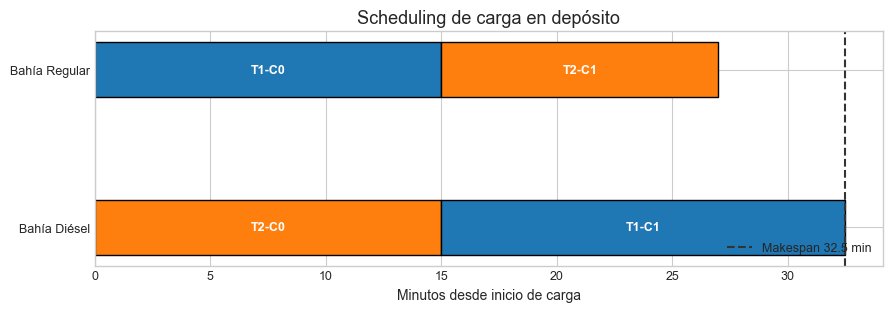

Figura guardada: figuras_ga\02_rutas_solucion_ga_1130.png


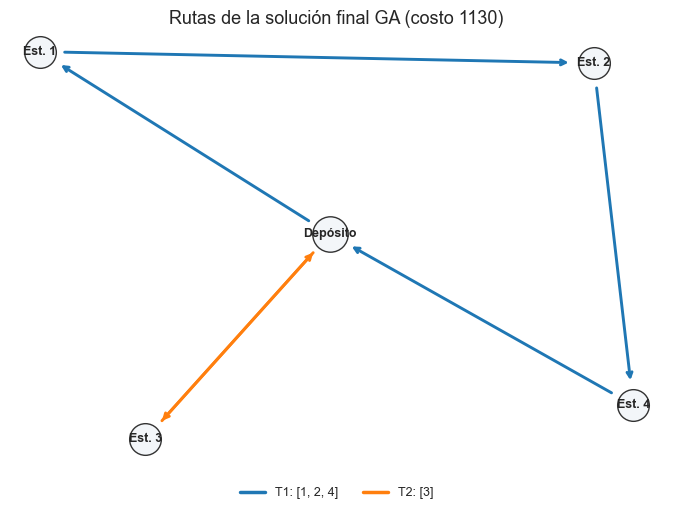

Figura guardada: figuras_ga\03_fill_ratios_solucion_ga_1130.png


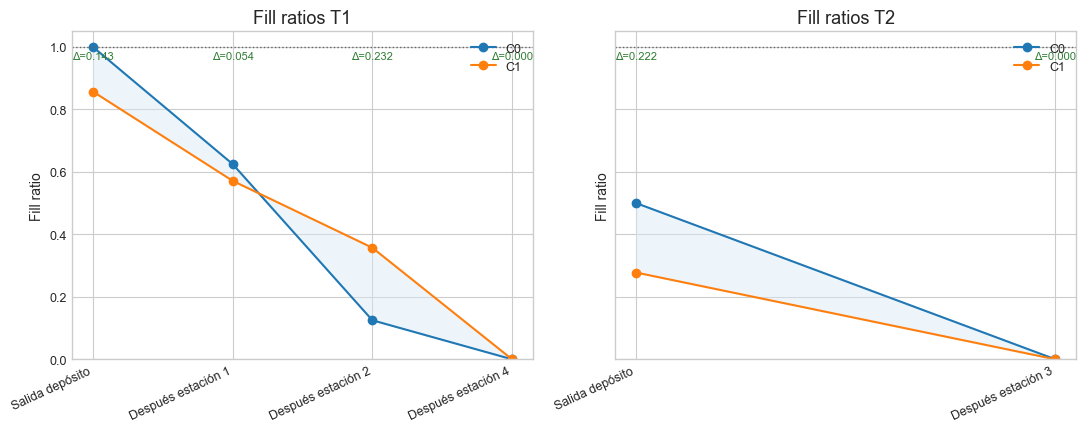

Figura guardada: figuras_ga\04_costos_solucion_ga_1130.png


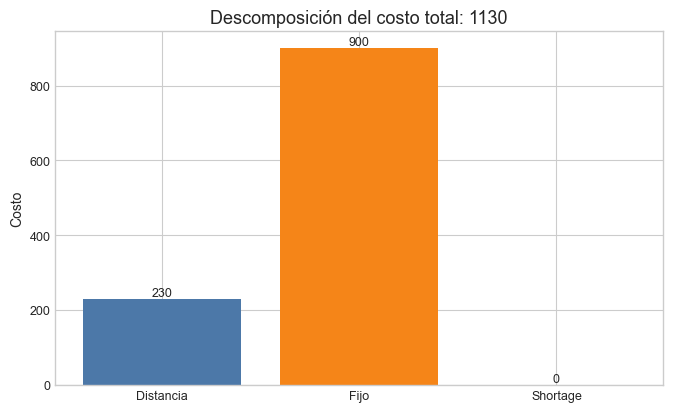

Figura guardada: figuras_ga\05_demanda_escenarios.png


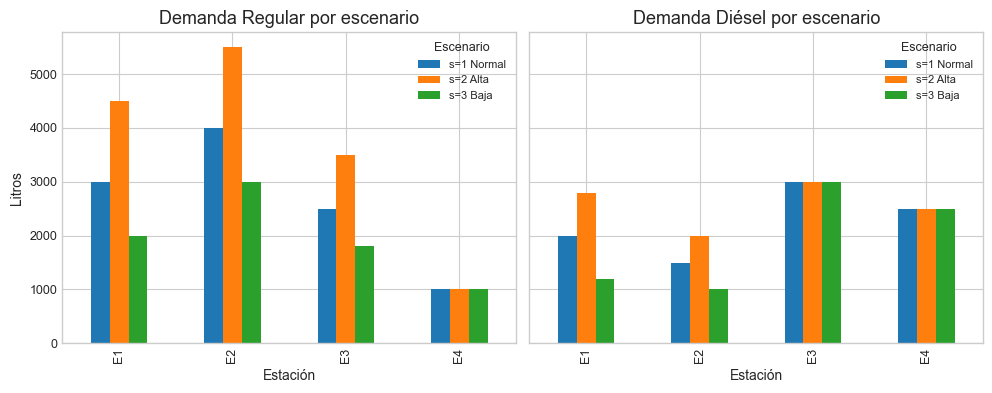

Figura guardada: figuras_ga\06_convergencia_ga_1130.png


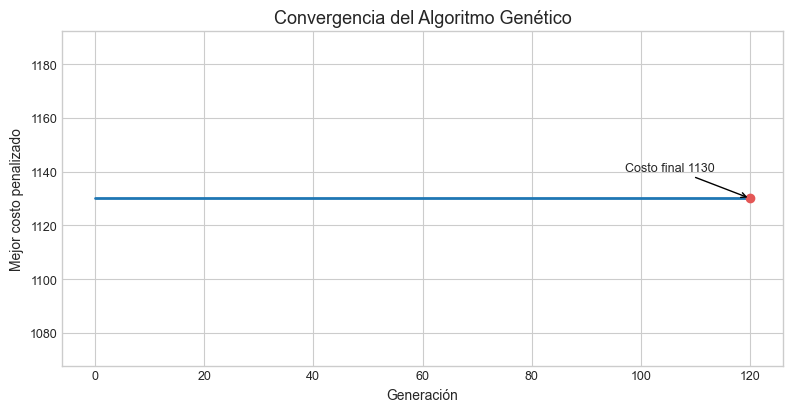

In [11]:
def guardar(fig, nombre: str):
    ruta = FIG_DIR / nombre
    fig.tight_layout()
    fig.savefig(ruta, dpi=180, bbox_inches="tight")
    print(f"Figura guardada: {ruta}")
    plt.show()


def plot_gantt_carga():
    colores = {"T1": "#1f77b4", "T2": "#ff7f0e"}
    y_pos = {"Regular": 1, "Diésel": 0}

    fig, ax = plt.subplots(figsize=(9, 3.2))
    for _, row in operaciones_carga.iterrows():
        ax.barh(
            y_pos[row["Bahía"]],
            row["Duración"],
            left=row["Inicio"],
            color=colores[row["Camión"]],
            edgecolor="black",
            height=0.35,
        )
        ax.text(
            (row["Inicio"] + row["Fin"]) / 2,
            y_pos[row["Bahía"]],
            row["Operación"],
            ha="center",
            va="center",
            color="white",
            weight="bold",
        )
    ax.axvline(makespan, color="#333333", linestyle="--", label=f"Makespan {makespan:.1f} min")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Bahía Diésel", "Bahía Regular"])
    ax.set_xlabel("Minutos desde inicio de carga")
    ax.set_title("Scheduling de carga en depósito")
    ax.legend(loc="lower right")
    guardar(fig, "01_gantt_carga.png")


def plot_rutas(resultado):
    posiciones = {
        0: (0.0, 0.0),
        1: (-1.1, 0.8),
        2: (1.0, 0.75),
        3: (-0.7, -0.9),
        4: (1.15, -0.75),
    }
    colores = {"T1": "#1f77b4", "T2": "#ff7f0e"}
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    for nodo, (x, y) in posiciones.items():
        ax.scatter(x, y, s=650 if nodo == 0 else 520, color="#F3F6F9", edgecolor="#333333", zorder=3)
        etiqueta = "Depósito" if nodo == 0 else f"Est. {nodo}"
        ax.text(x, y, etiqueta, ha="center", va="center", weight="bold", zorder=4)

    for camion, ruta in resultado["rutas"].items():
        secuencia = [0] + ruta + [0]
        for i in range(len(secuencia) - 1):
            a, b = secuencia[i], secuencia[i + 1]
            x1, y1 = posiciones[a]
            x2, y2 = posiciones[b]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=2.1, color=colores[camion], shrinkA=18, shrinkB=18),
            )
        ax.plot([], [], color=colores[camion], lw=2.5, label=f"{camion}: {ruta}")

    ax.set_title("Rutas de la solución final GA (costo 1130)")
    ax.set_axis_off()
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=2)
    guardar(fig, "02_rutas_solucion_ga_1130.png")


def plot_fill_ratios(resultado):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
    for ax, camion in zip(axes, ["T1", "T2"]):
        sub = resultado["fill"][resultado["fill"]["camion"] == camion].reset_index(drop=True)
        x = np.arange(len(sub))
        ax.plot(x, sub["rho_C0"], marker="o", label="C0")
        ax.plot(x, sub["rho_C1"], marker="o", label="C1")
        ax.fill_between(x, sub["rho_C0"], sub["rho_C1"], color="#D9EAF7", alpha=0.45)
        ax.axhline(1.0, color="#666666", linestyle=":", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["evento"], rotation=25, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Fill ratios {camion}")
        ax.set_ylabel("Fill ratio")
        ax.legend(loc="upper right")
        for idx, diff in enumerate(sub["diferencia"]):
            ax.text(idx, 0.96, f"Δ={diff:.3f}", ha="center", color="#2E7D32", fontsize=8)
    guardar(fig, "03_fill_ratios_solucion_ga_1130.png")


def plot_costos(resultado):
    datos = pd.DataFrame([
        {
            "Componente": "Distancia",
            "Costo": resultado["costo_distancia"],
        },
        {
            "Componente": "Fijo",
            "Costo": resultado["costo_fijo"],
        },
        {
            "Componente": "Shortage",
            "Costo": resultado["costo_shortage"],
        },
    ])
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    bars = ax.bar(datos["Componente"], datos["Costo"], color=["#4C78A8", "#F58518", "#E45756"])
    ax.bar_label(bars, labels=[f"{v:.0f}" for v in datos["Costo"]])
    ax.set_title("Descomposición del costo total: 1130")
    ax.set_ylabel("Costo")
    guardar(fig, "04_costos_solucion_ga_1130.png")


def plot_escenarios():
    registros = []
    for escenario, info in ESCENARIOS.items():
        for estacion, demanda in info["demanda"].items():
            for producto in ["R", "D"]:
                registros.append({
                    "escenario": escenario,
                    "estacion": f"E{estacion}",
                    "producto": PRODUCTOS[producto],
                    "litros": demanda[producto],
                })
    df = pd.DataFrame(registros)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for ax, producto in zip(axes, ["Regular", "Diésel"]):
        pivot = df[df["producto"] == producto].pivot(index="estacion", columns="escenario", values="litros")
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(f"Demanda {producto} por escenario")
        ax.set_xlabel("Estación")
        ax.set_ylabel("Litros")
        ax.legend(title="Escenario", fontsize=8)
    guardar(fig, "05_demanda_escenarios.png")


def plot_convergencia(historia):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(historia["generacion"], historia["mejor_costo_penalizado"], color="#1f77b4", lw=2)
    ax.set_title("Convergencia del Algoritmo Genético")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Mejor costo penalizado")
    ax.scatter(historia["generacion"].iloc[-1], historia["mejor_costo_penalizado"].iloc[-1], color="#E45756", zorder=3)
    ax.annotate(
        "Costo final 1130",
        xy=(historia["generacion"].iloc[-1], historia["mejor_costo_penalizado"].iloc[-1]),
        xytext=(-90, 20),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
    )
    guardar(fig, "06_convergencia_ga_1130.png")


plot_gantt_carga()
plot_rutas(res_ga)
plot_fill_ratios(res_ga)
plot_costos(res_ga)
plot_escenarios()
plot_convergencia(historia_ga)


## 11. Figuras generadas

Las figuras quedan disponibles en `figuras_ga/`.

![Gantt](figuras_ga/01_gantt_carga.png)

![Rutas](figuras_ga/02_rutas_solucion_ga_1130.png)

![Fill ratios](figuras_ga/03_fill_ratios_solucion_ga_1130.png)

![Costos](figuras_ga/04_costos_solucion_ga_1130.png)

![Escenarios](figuras_ga/05_demanda_escenarios.png)

![Convergencia](figuras_ga/06_convergencia_ga_1130.png)


## 12. Conclusión técnica

La solución construida mediante Algoritmo Genético es factible y cubre toda la demanda del escenario normal.

Resumen:

```text
T1: Depósito -> 1 -> 2 -> 4 -> Depósito
T2: Depósito -> 3 -> Depósito
Distancia total = 115 km
Costo distancia = 230
Costos fijos = 900
Shortage = 0
Costo total = 1130
```

La verificación computacional confirma capacidad, estabilidad de carga, ventanas de tiempo y satisfacción
de demanda.
